### 1. A gaussian integral

Using Monte Carlo integration, check that

$$ \int_0^\infty x^3 \exp\left(-\frac{x^2}{2\sigma^2}\right) \,dx = 2\sigma^4 .$$

- Does the result converge with the number of samples? And how does the error go down?
- Do it many times. For a given $N$, how are the result distributed? We'll talk about model fitting at lenght later on, but for now try to fit it by hand with a parametrized model. (If N is large enough you should get something that looks *very* accurate! And if $N$ is small?)
- How does the distribution change if $N$ increases?

(Hint: think about sample mean and sample variance)

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

To apply the Monte Carlo integration method, we must have $f(x)\:p(x)$, with $p(x)$ being a normalized function over the integration interval.

Given our initial function in the integral, it's easy to recunstract a Gaussian pdf with $\mu = 0$ such that $p(x) = Gauss$. 
In order to do that we have to divide and multiply by $\sigma \sqrt{2\pi}$, having then $f(x) = \sigma \sqrt{2\pi} x^3$

Nevertheless, a normal pdf is normalized over the interval $(-\infty, +\infty)$, while we are only interested in $(0, +\infty)$. 
In order to solve this, we will simply consider a Gaussian Distribution and multiply the expected result by a factor 2 as our $p(x)$ as to be twice a half-gaussian in ordere to be normalized over the interval in which we are working. 

In [2]:
sigma = 2 #Define a value for sigma
N = 1000 #Number of samples to draw
gauss = stats.norm(0,sigma) #Setting up the gaussian distribution 
samples = np.abs(gauss.rvs(N))  #As we are integrating from zero to inf, we have to only take samples from this interval
sol = 4*(sigma**4) #As we have to have a distribution normalized over the 

In [3]:
I = sigma * np.sqrt(2*np.pi)*np.mean(samples**3)
print('Monte Carlo solution:', I)
print('Expected solution is:', sol)
print('Error:', np.abs(I-sol)/I)

Monte Carlo solution: 66.26121272936973
Expected solution is: 64
Error: 0.03412573715795376


Let's check if the result converge with the number of samples and how does the error go down.

In [6]:
N = 10000
I_k = np.zeros(N)
for k in range(N):
    samples_k = np.abs(gauss.rvs(k+1))
    I_k[k] = sigma * np.sqrt(2*np.pi)*np.mean(samples_k**3)

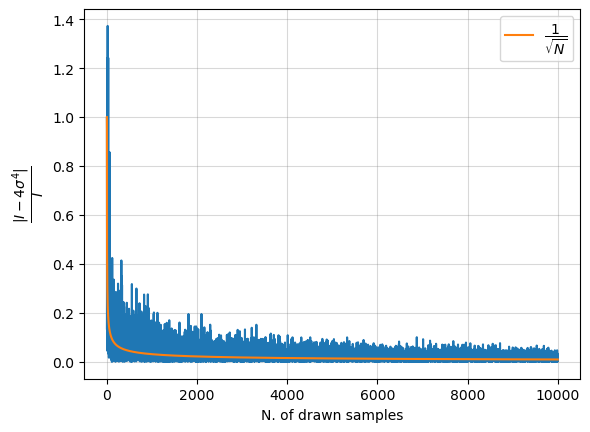

In [17]:
x = np.arange(1,N+1)
plt.plot(x, np.abs((I_k-sol))/sol,)
plt.grid(c = 'gray', alpha = 0.3)
plt.xlabel('N. of drawn samples')
plt.ylabel(r'$\dfrac{|I - 4\sigma^4|}{I}$')
plt.plot(x, x**-0.5, label = r'$\dfrac{1}{\sqrt{N}}$')
plt.legend()

Let's now redo our computations many times with a fixed number of samples N, how are the results distributed ? Does it change for a low value of N ?

  0%|          | 0/1000 [00:00<?, ?it/s]

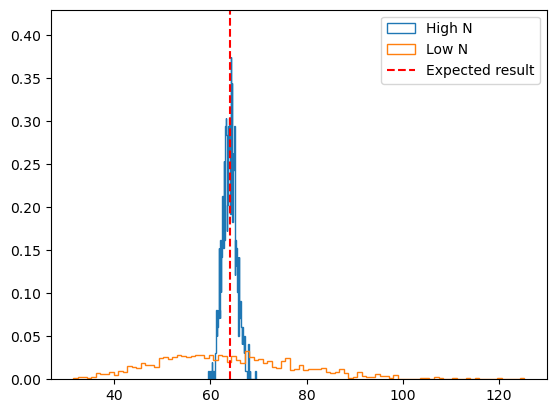

In [8]:
N_t_max = 10000 #Number of samples to draw
N_t_min = 100
times = 1000 #Number of times we redo the sample drawing 
I_t_max = np.zeros(times)
I_t_min = np.zeros(times)

for i in tqdm(range(times)):
    samples_max = np.abs(gauss.rvs(N_t_max))
    samples_min = np.abs(gauss.rvs(N_t_min))
    I_t_max[i] = sigma * np.sqrt(2*np.pi)*np.mean(samples_max**3)
    I_t_min[i] = sigma * np.sqrt(2*np.pi)*np.mean(samples_min**3)

plt.hist(I_t_max, bins = 100, histtype='step', density = True, label = 'High N')
plt.hist(I_t_min, bins = 100, histtype='step', density = True, label = 'Low N')
plt.vlines(sol, 0, 0.43, color = 'r', linestyle = '--', label = 'Expected result')
plt.ylim(0, 0.43)
plt.legend()

The results we get with a higher number of samples are clearly distributed closer to the expected result!

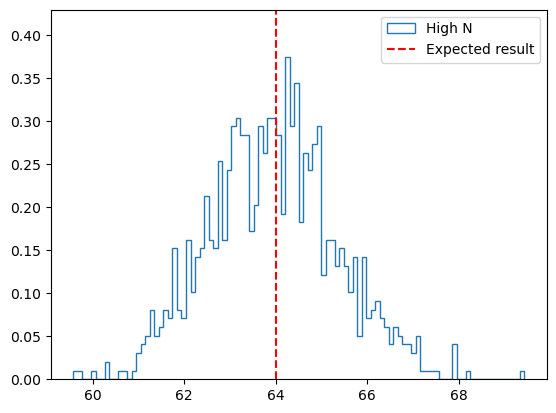

In [9]:
plt.hist(I_t_max, bins = 100, histtype='step', density = True, label = 'High N')
plt.vlines(sol, 0, 0.43, color = 'r', linestyle = '--', label = 'Expected result')
plt.ylim(0, 0.43)
plt.legend()

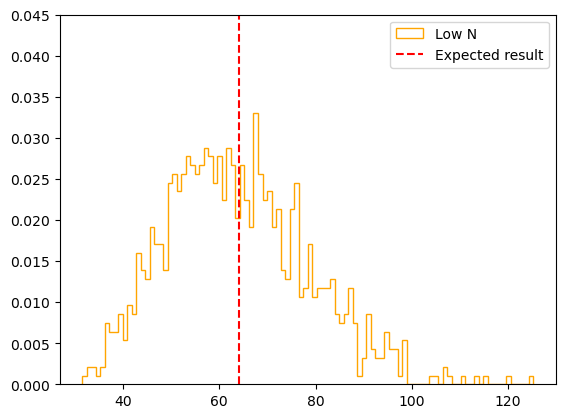

In [10]:
plt.hist(I_t_min, bins = 100, histtype='step', density = True, label = 'Low N', color='orange')
plt.vlines(sol, 0, 0.43, color = 'r', linestyle = '--', label = 'Expected result')
plt.ylim(0, 0.045)
plt.legend()

The distribution resembles a Gaussian centered in the expected result of our integral. 

Let's try to overplot such a function.

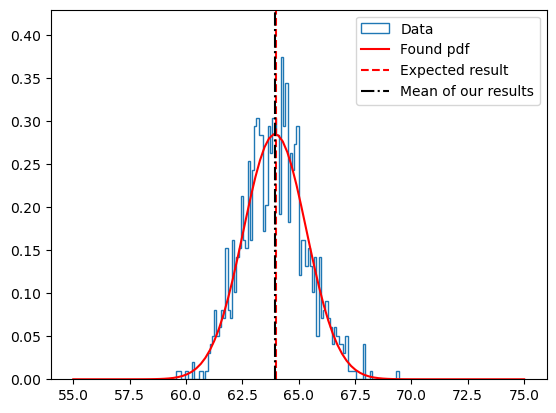

In [11]:
sigma_res = np.std(I_t_max)
mu_res = np.mean(I_t_max)
pdf_res = stats.norm(mu_res, sigma_res)

x_res = np.linspace(55, 75, 100)
plt.hist(I_t_max, bins = 100, histtype='step', density = True, label = 'Data')
plt.plot(x_res, pdf_res.pdf(x_res), 'r-', label = 'Found pdf')
plt.vlines(sol, 0, 0.43, color = 'r', linestyle = '--', label = 'Expected result')
plt.vlines(mu_res, 0, 0.43, color = 'black', linestyle = '-.', label = 'Mean of our results')
plt.ylim(0, 0.43)
plt.legend()

Let's now check how the pdf of our results changes with N:

In [12]:
Ns = [100, 1000, 10000, 100000]
times = 1000 #Number of times we redo the sample drawing 
I_t = np.zeros((times, len(Ns)))


for i in tqdm(range(times)):
    for k in range(len(Ns)):
        samples = np.abs(gauss.rvs(Ns[k]))
        I_t[i, k] = sigma * np.sqrt(2*np.pi)*np.mean(samples**3)
        
mus = np.mean(I_t, axis = 0)
stds = np.std(I_t, axis = 0)
pdfs = [stats.norm(loc=mu, scale=sigma) for mu, sigma in zip(mus, stds)]

  0%|          | 0/1000 [00:00<?, ?it/s]

(-0.01, 0.95)

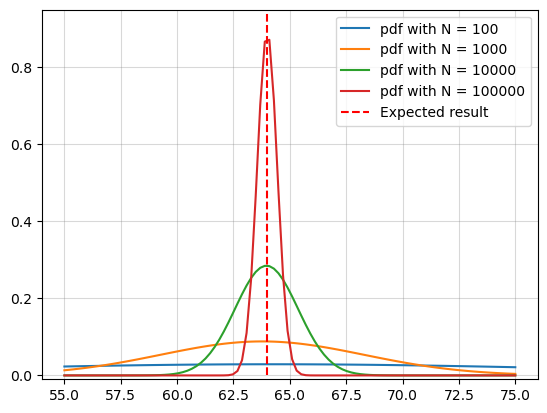

In [13]:
for i in range(len(pdfs)):
    plt.plot(x_res, pdfs[i].pdf(x_res), label = f'pdf with N = {Ns[i]}')

plt.vlines(sol, 0, 1, color = 'r', linestyle = '--', label = 'Expected result')
plt.legend()
plt.grid(c = 'gray', alpha = 0.3)
plt.ylim(-0.01, 0.95)